# RAPID-MFA-8: Splitting inflows for maintenance and for expansion

## Descriptions

Inflows can be dissagregated by their roles, differentiating between:

__Inflows for maintenance (replacement)__ are necessary to maintain a given stock level, compensating for outflows: as in-stock cohorts have yearly outflows, these must be balanced with maintance inflows to maintain the stock level. 

__Inflows for expansion__ increase the stocks beyond the stocks' previous amounts. 

## Two cases of maintenance and expansion

In growing or completely stable stocks, the decomposition of inflows to maintenance and expansion is straightforward: Maintenance inflows fully compensate for outflows, and expansions are identical to the positive change of stocks:

In decreasing stocks, all inflows go towards incompletely compensating for the outflows, and there are insufficient inflows to expand the stocks. In such a case, the negative-valued stock changes are the gap between outflows and the insufficient maintenance inflows.

$$
\begin{align}
\textcolor{#8E795E}{\text{stock\_changes}(t)} &\geq 0 \begin{cases}
\textcolor{#277989}{\text{maintenance\_inflows}(t)} &= \textcolor{#D19F37}{\text{outflows}(t)} \\
\textcolor{#60BFD2}{\text{expansion\_inflows}(t)} &= \textcolor{#8E795E}{\text{stock\_changes}(t)}
\end{cases}
\end{align}
$$

In decreasing stocks, all inflows go towards incompletely compensating for the outflows, and there are insufficient inflows to expand the stocks. In such a case, the negative-valued stock changes are the gap between outflows and the insufficient maintenance inflows.

$$
\begin{align}
\textcolor{#8E795E}{\text{stock\_changes}(t)} &< 0 \begin{cases}
\textcolor{#277989}{\text{maintenance\_inflows}(t)} &= \textcolor{#2A8596}{\text{inflows}(t)} \\
\textcolor{#60BFD2}{\text{expansion\_inflows}(t)} &= 0
\end{cases}
\end{align}
$$



## Notes
1. In both the stock-driven model and the flow-driven model, the separation of inflows to maintenance and expansion can only be done after the full system (inflows, outflows, stock changes, and stocks) have been calculated. 

2. Code cell 7 is the heart of this notebook, in which the inflows are separated into maintenance and expansion flows.

3. The example in this RAPID MFA notebook uses a stock driven model, but code cell 7 can be used with the results of a flow driven model without any modification (see the note 1)

4. In an MFA system that converts flows and stocks from the layer of service or products into the layer of flows and stocks of materials (i.e. `RAPID-MFA-9: Switching from products/services to materials with changing material compositions` and models derived from it), the split of inflows to maintenance and expansion must be run twice, once for the products-layer system and once for the materials-layer system. Direct conversion by multiplying all flows and stocks by material intensities creates incorrect results, because the stocks and outflows of the materials layer are composed of mixed cohorts with varying material compositions.


### Relations with other RAPID-MFA codes
- `RAPID-MFA-2: The stock driven model`: the basic model to calculate flows and stocks for this example. Can be swapped with a flow-driven model, see notes above.


### Exogenous input variables used in this example

The example uses offshore wind turbines in units of generation capacity (MW), simplified from [Fishman and Graedel 2019](https://doi.org/10.1038/s41893-019-0252-z):

__Stocks:__ Nationwide, central scenario, simplified from [Fishman and Graedel 2019](https://doi.org/10.1038/s41893-019-0252-z) 

__Survival curve:__ Normal distribution, $mean=20$ from [Fishman and Graedel 2019](https://doi.org/10.1038/s41893-019-0252-z), $SD=(mean/2)$ modified for this example. s

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 


## 1. Load libraries

In [61]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

## 2. Define example input data

In [62]:
# %% 2. Define example input data

input_data = pd.Series([0, 30, 30, 30, 30, 30, 2985, 6523, 8721,
                        10171, 11851, 13772, 15729, 17621, 19480, 21761, 24793, 27959,
                        30680, 33460, 36803, 40144, 42956, 45948, 49759, 53522, 56405,
                        59223, 62825, 66555, 69664, 72539, 75776, 75776, 75000, 74234],
                        name = 'stocks', 
                        index = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 
                                 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 
                                 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 
                                 2045, 2046, 2047, 2048, 2049, 2050]) # megawatts installed capacity of wind turbines

ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data
mean = 20  # offshore turbines have a mean lifespan of 20 years (see Fishman and Graedel 2019)
std_dev = 10  # for this example, changed from sd = 5 in Fishman and Graedel 2019
survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)


## 3. Set up the MFA system

<Axes: ylabel='MW'>

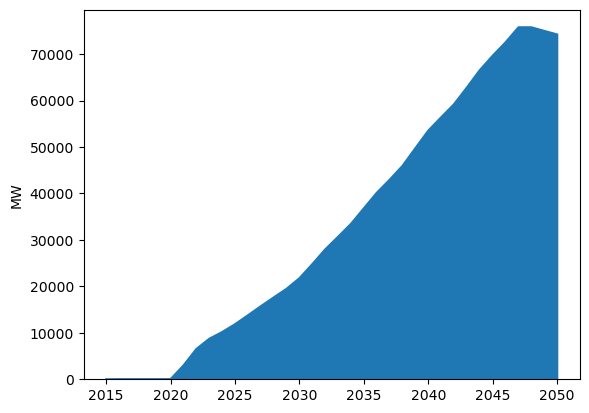

In [63]:
# %% 3. Set up the MFA system
units = {'time_interval':   'year', 
         'flows':           'MW/year', 
         'stocks':          'MW'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

time_interval = 1

cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required


mfa_system = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])


mfa_system['stocks'] = input_data
mfa_system['stocks'].plot(kind="area", stacked=True, ylabel=units['stocks'])

## 4. Create the survival curves matrix

In [64]:
# %% 4. Create survival curves matrix
# create survival curves matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]


## 5. Calculate the MFA system

In this example the stocks of the product (turbines in MW of energy generation) is given so this step is a stock-driven model, but can be replaced with a flow-driven model if inflows are the exogenous input data.

In [65]:
# %% 5. Calculate the MFA system of the products layer

# Stock-driven model in this example.

# Create cohorts survival matrix and calculate the inflows
# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it while creating each inflow
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system.loc[cohort, 'inflows'] = (
        mfa_system.loc[cohort, 'stocks'] - cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system.loc[cohort, 'inflows']

# calculate stock changes (net change to stock)
# prepend=0 replicates the convention that stock_change is the difference between current timeframe and previous timeframe. 
mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)

# Calculate outflows using mass balance
mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]


## 6. Calculate the expansion and maintenance components of the inflows

In [66]:
# %% 6. Calculate the expansion and maintenance components of the inflows

mfa_system['expansion'] = np.where(mfa_system['stock_changes'] < 0, 0, mfa_system['stock_changes'])  # in timeframes in which the stock change is negative, no expansion happened so expansion=0. If stock change is positive, this is the expansion.
mfa_system['maintenance'] = mfa_system['inflows'] - mfa_system['expansion']  # maintenance is the inflow that was not used for expansion.


### 7.1 Plot the maintenance and expansion flows

<Axes: ylabel='flows [kg/year]'>

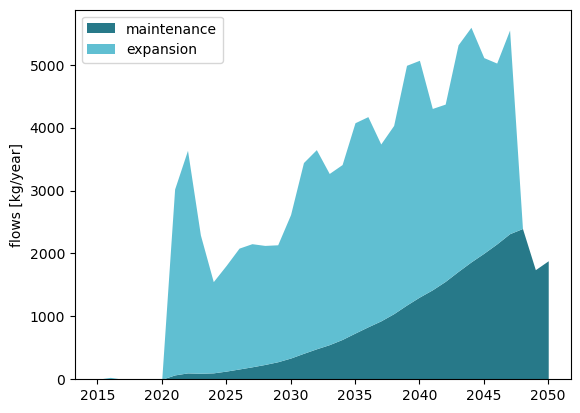

In [67]:
# Visualize the maintenance and expansion composition of the inflows.
mfa_system[['maintenance', 'expansion']].plot(kind="area", 
                                              color=["#277989", "#60BFD2"],
                                              lw=0,
                                              ylabel="flows [kg/year]", 
                                              )

### 7.2 Additional analysis figures

Expansion inflows are equal to stock changes only when stock changes are positive (net addition to stocks):

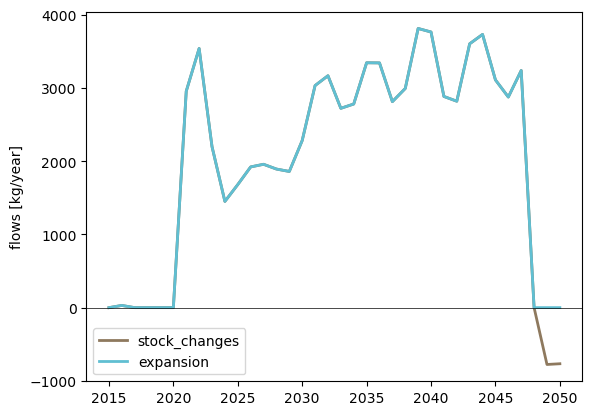

In [73]:
mfa_system[['stock_changes', 'expansion']].plot(kind="line", 
                                                color=["#8E795E", "#60BFD2"],
                                                lw=2,
                                                ylabel="flows [kg/year]", 
                                                )
plt.axhline(0, color="000", lw=0.5)

When stocks grow or stabilize, maintenance inflows are equal to outflows; and when stocks decline, maintenance inflows are lower than outflows:

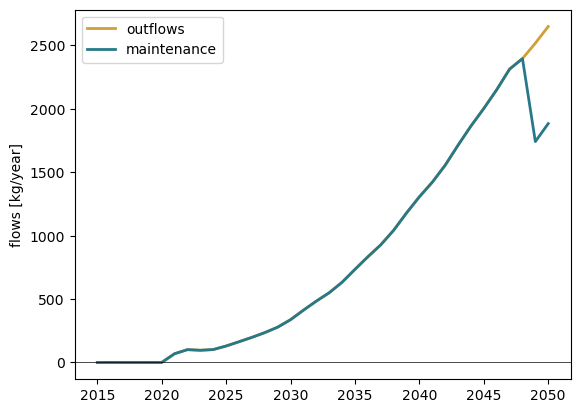

In [75]:
mfa_system[['outflows', 'maintenance']].plot(kind="line", 
                                              color=["#D19F37", "#277989"],
                                              lw=2,
                                              ylabel="flows [kg/year]", 
                                              )
plt.axhline(0, color="000", lw=0.5)

These phenomena can also be seen in the stocks by cohorts figure:

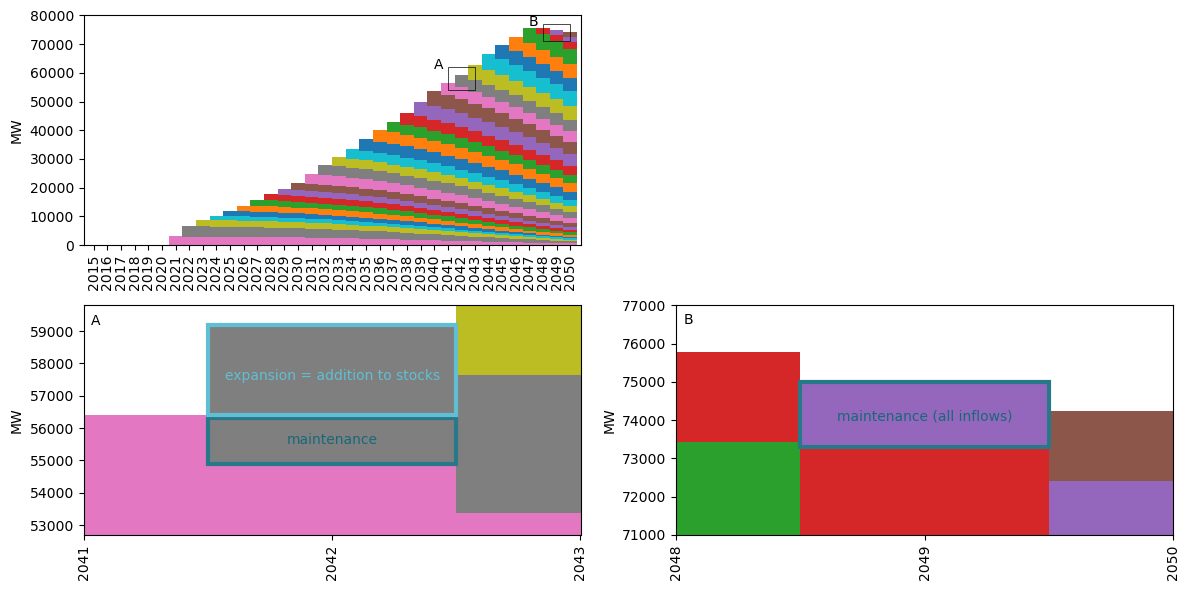

In [77]:
# plot stocks by cohorts
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 6), tight_layout=True)

cohorts_survival_matrix.plot(kind="bar", stacked=True, width=1, lw=0, 
                             legend=False, ylabel=units['stocks'],
                             ylim=(0, 80000),
                             ax=ax[0,0])

ax[0,0].add_patch(Rectangle((26, 54100), 
                             2, 8000,
                             edgecolor='black',
                             facecolor='none',
                             lw=.5))
ax[0,0].text(25.3, 61500, "A", horizontalalignment='center')


ax[0,0].add_patch(Rectangle((33, 71200), 
                             2, 5700,
                             edgecolor='black',
                             facecolor='none',
                             lw=.5))
ax[0,0].text(32.3, 76300, "B", horizontalalignment='center', )

# zoom in to 2042
cohorts_survival_matrix.plot(kind="bar", stacked=True, width=1, lw=0, 
                             legend=False, ylabel=units['stocks'],
                             ax=ax[1,0])
ax[1,0].set(xlim=(26,28), ylim=(52700,59800))
ax[1,0].text(26.05, 59200, "A", horizontalalignment='center')

ax[1,0].add_patch(Rectangle((26.5, 54900), 
                             1, 1425,
                             edgecolor='#277989',
                             facecolor='none',
                             lw=3))
ax[1,0].text(27, 55500, "maintenance", horizontalalignment='center', color="#186879")

ax[1,0].add_patch(Rectangle((26.5, 56400), 
                             1, 2800,
                             edgecolor="#60BFD2",
                             facecolor='none',
                             lw=3))
ax[1,0].text(27, 57500, "expansion = addition to stocks", horizontalalignment='center', color="#60BFD2")

# zoom in to 2049
cohorts_survival_matrix.plot(kind="bar", stacked=True, width=1, lw=0, 
                             legend=False, ylabel=units['stocks'],
                             ax=ax[1,1])
ax[1,1].set(xlim=(33,35), ylim=(71000,77000))
ax[1,1].text(33.05, 76500, "B", horizontalalignment='center')

ax[1,1].add_patch(Rectangle((33.5, 73300), 
                             1, 1700,
                             edgecolor='#277989',
                             facecolor='none',
                             lw=3))
ax[1,1].text(34, 74000, "maintenance (all inflows)", horizontalalignment='center', color="#186879")

ax[0,1].remove()